# 🔋 Appliances Energy Prediction Project

**Objective:**  
This project aims to predict the energy consumption of household appliances using the **UCI Appliances Energy Prediction dataset**.  
We apply **correlation-based feature selection** and build **ten incremental multiple linear regression models** to examine how the number of features impacts predictive performance.

**Keywords:** Machine Learning, Feature Selection, Linear Regression, MSE, MAPE

## 1. Introduction

Energy consumption forecasting is an essential part of smart home systems, allowing for more efficient energy management and planning.  
The main goal of this project is to develop predictive models that estimate appliance energy usage based on environmental and operational variables.  

We adopt a simple yet effective modeling approach:
- Select features based on their Pearson correlation with the target variable.
- Incrementally add features to the model (from 1 to 10).
- Evaluate and compare model performance using **Mean Squared Error (MSE)** and **Mean Absolute Percentage Error (MAPE)**.

## 2. Importing Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## 3. Data Loading and Preprocessing

The dataset used in this project is the **Appliances Energy Prediction Dataset** from the UCI Machine Learning Repository.  
It contains measurements such as temperature, humidity, pressure, and lighting conditions recorded every 10 minutes.

We perform the following preprocessing steps:
- Remove irrelevant columns (`date`, `rv1`, `rv2`).
- Define the target variable (`Appliances`) and predictor features.
- Split the dataset into **70% training** and **30% testing** sets.

In [9]:
# Load dataset
df = pd.read_csv("D:/Veri_Bilimi/Proje_ödev/veri seti uygulamalar/energydata_complete.csv")

# Drop irrelevant columns
df = df.drop(columns=["date", "rv1", "rv2"], errors="ignore")

# Define target and features
y = df["Appliances"]
X = df.drop(columns=["Appliances"])

# Split data (70% train / 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, shuffle=True
)

X_train.shape, X_test.shape

((13814, 25), (5921, 25))

## 4. Correlation Analysis and Feature Selection

To identify the most influential features, we compute the **Pearson correlation coefficient** between each feature and the target variable.  
The features are then ranked by the **absolute value** of their correlation.

The top 10 features are selected for the incremental modeling process. This approach helps reduce dimensionality, improve interpretability, and potentially enhance model performance.

In [10]:
# Compute Pearson correlation with the target
correlations = X_train.corrwith(y_train)

# Sort by absolute correlation
top10_features = correlations.abs().sort_values(ascending=False).head(10)
top10_features

lights       0.197032
RH_out       0.149512
T2           0.118070
T6           0.114261
T_out        0.096338
RH_8         0.091740
RH_1         0.089001
Windspeed    0.086354
T3           0.080569
RH_6         0.077456
dtype: float64

### Figure 4.1 – Top 10 Features by Absolute Pearson Correlation

The following bar plot visualizes the top 10 features with the strongest linear relationship to the energy consumption variable (`Appliances`).  
Higher correlation values indicate a stronger predictive relationship.

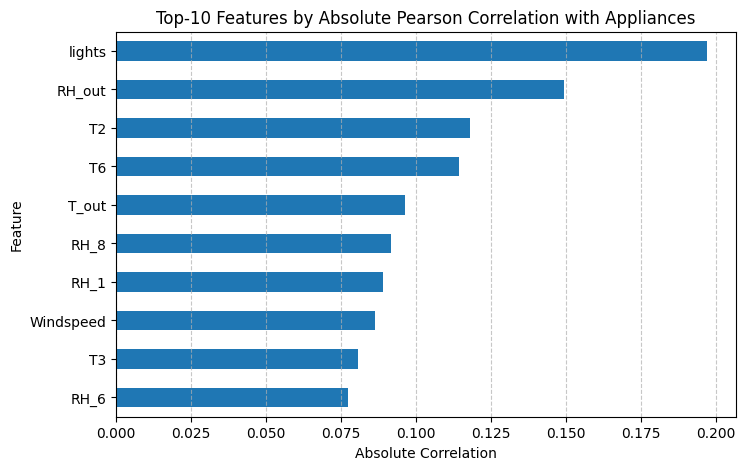

In [11]:
plt.figure(figsize=(8,5))
top10_features.sort_values().plot(kind='barh')
plt.title("Top-10 Features by Absolute Pearson Correlation with Appliances")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 5. Incremental Linear Regression Models

We build a series of **10 multiple linear regression models**, each with an increasing number of features (from 1 to 10).  
Model 1 uses only the most correlated feature, while Model 10 includes the top 10 features.

For each model, we calculate:
- **MSE (Mean Squared Error):** Measures the average squared difference between predicted and actual values.
- **MAPE (Mean Absolute Percentage Error):** Expresses the average prediction error as a percentage of the actual values.

In [12]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []

# Build 10 incremental models
for i in range(1, 11):
    features = top10_features.index[:i]
    model = LinearRegression()
    model.fit(X_train[features], y_train)
    y_pred = model.predict(X_test[features])
    
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    results.append([i, mse, mape])

results_df = pd.DataFrame(results, columns=["Num_Features", "MSE", "MAPE"])
results_df

,Num_Features,MSE,MAPE
0,1,9899.283200,72.418277
1,2,9594.378739,68.261101
2,3,9574.976333,67.519770
3,4,9567.415121,67.504176
4,5,9481.635772,67.120064
5,6,9475.823916,66.697637
6,7,9188.376614,64.704304
7,8,9162.708033,64.807745
8,9,9116.442792,64.392822
9,10,9064.290865,65.031676


## 6. Model Performance Comparison

The figure below (Figure 6.1) illustrates how **MSE** and **MAPE** values change as the number of features increases.  
This visualization helps us understand the trade-off between model complexity and performance.

### Figure 6.1 – MSE and MAPE Values vs. Model Complexity

- The **blue line** represents the MSE values (left axis).
- The **red line** shows the MAPE percentages (right axis).
- As more features are added, both MSE and MAPE generally decrease, indicating improved predictive performance.
- However, diminishing returns occur after a certain point, highlighting the importance of balancing model complexity and accuracy.

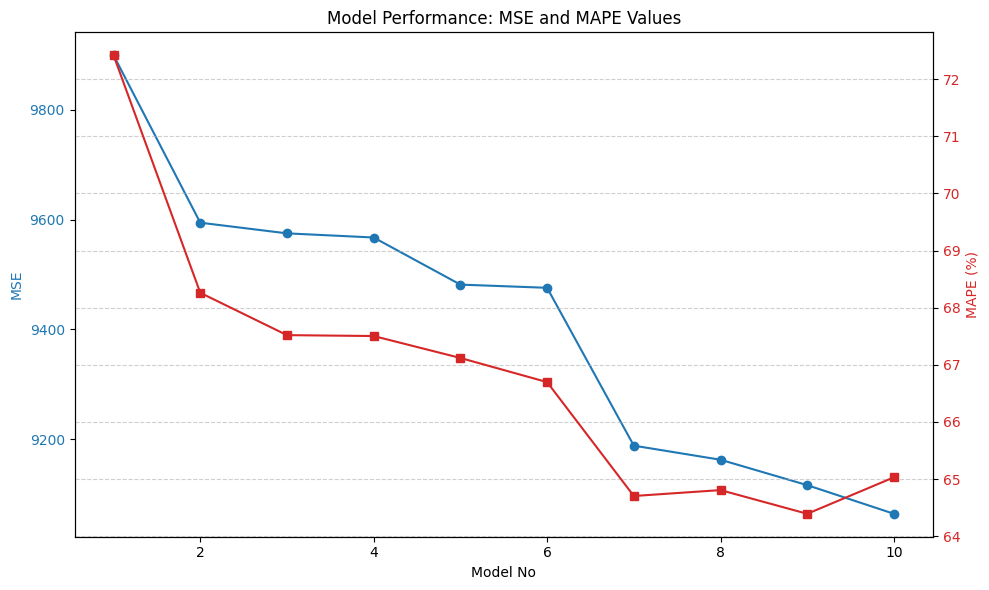

In [14]:
# Sample results (replace with your real results_df values)
models = results_df["Num_Features"]
mse = results_df["MSE"]
mape = results_df["MAPE"]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot MSE (left axis)
color = 'tab:blue'
ax1.set_xlabel("Model No")
ax1.set_ylabel("MSE", color=color)
ax1.plot(models, mse, color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)

# Plot MAPE (right axis)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel("MAPE (%)", color=color)
ax2.plot(models, mape, color=color, marker='s')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title("Model Performance: MSE and MAPE Values")
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 7. Best Model Analysis

We identify the models with the lowest MSE and MAPE scores and analyze their feature sets.  
In many cases, the best-performing model in terms of MSE may not be the same as the one that minimizes MAPE.

This discrepancy demonstrates the **bias–variance trade-off**:
- Models with more features often achieve lower errors but risk overfitting.
- Simpler models may generalize better but have slightly higher errors.

In [15]:
best_mse_model = results_df.loc[results_df["MSE"].idxmin()]
best_mape_model = results_df.loc[results_df["MAPE"].idxmin()]

print("📉 Best MSE Model:")
print(best_mse_model)
print("\n📊 Best MAPE Model:")
print(best_mape_model)

📉 Best MSE Model:
Num_Features      10.000000
MSE             9064.290865
MAPE              65.031676
Name: 9, dtype: float64

📊 Best MAPE Model:
Num_Features       9.000000
MSE             9116.442792
MAPE              64.392822
Name: 8, dtype: float64


## 8. Conclusion

- Correlation-based feature selection is a simple yet effective technique for improving model interpretability and reducing dimensionality.
- Incremental model building demonstrates that performance improves as more features are added, but the improvement slows after a certain threshold.
- Choosing the best model depends on the evaluation metric (MSE vs. MAPE) and the balance between interpretability and accuracy.
- Future work may include exploring non-linear models (e.g., Random Forest, Gradient Boosting) or time-series forecasting methods to capture temporal dynamics in the data.